# Ana for EPB

In [1]:
#regular packages
import pandas as pd
import string
import numpy as np
import os

#nlp packages
import nltk
import contractions
from nltk.corpus import stopwords
#nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.stem.porter import *

from bertopic import BERTopic

In [ ]:
#import nltk
#nltk.download('punkt')
#nltk.download('stopwords')
#import ssl

#try:
#    _create_unverified_https_context = ssl._create_unverified_context
#except AttributeError:
#    pass
#else:
#    ssl._create_default_https_context = _create_unverified_https_context#

#nltk.download()

In [ ]:
common_words = [
    "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", "finding", "feature", "also", "and",
    "the", "be", "to", "of", "and", "a", "in", "that", "have", "I", "it", "for", "not", "on", "with", "he", "as", 
    "you", "do", "at", "this", "but", "his", "by", "from", "they", "say", "her", "she", "or", "an", "will", 
    "my", "one", "all", "would", "there", "their", "what", "so", "up", "out", "if", "about", "who", "get", "which", 
    "go", "me", "when", "make", "can", "like", "time", "no", "just", "him", "know", "take", "people", "into", "year", 
    "your", "good", "some", "could", "them", "see", "other", "than", "then", "now", "look", "only", "come", "its", 
    "over", "think", "also", "back", "after", "use", "two", "how", "our", "work", "first", "well", "way", "even", 
    "new", "want", "because", "any", "these", "give", "day", "most", "us", "is", "are", "was", "been", 
    "being", "had", "has", "do", "does", "did", "am", "are", "is", "were", "be", "being", "been", "have", 
    "has", "had", "do", "does", "did", "can", "could", "will", "would", "shall", "should", "may", "might", "must", 
    "ought", "there", "here", "where", "when", "why", "how", "what", "which", "who", "whom", "whose", "if", "though", 
    "since", "unless", "until", "while", "because", "so", "so that", "in order that", "that", "lest", "lest", "rather", 
    "whether", "who", "whoever", "whomever", "whichever", "whatever", "he", "him", "his", "she", "her", "hers", "it", 
    "its", "they", "them", "their", "theirs", "we", "us", "our", "ours", "you", "your", "yours", "ye", "thee", "thou", 
    "thine", "my", "mine", "our", "ours", "your", "yours", "his", "her", "its", "their", "theirs", "n't", "d", "ll", 
    "m", "o", "re", "s", "t", "ve", "y", "ain", "aren", "couldn", "didn", "doesn", "hadn", "hasn", "haven", "isn", 
    "ma", "mightn", "mustn", "needn", "shan", "shouldn", "wasn", "weren", "won", "wouldn", "also", "am", "am", "aren",
    "aren", "be", "be", "because", "been", "been", "being", "being", "both", "but", "by", "can", "couldn", "couldn", 
    "did", "didn", "didn", "do", "does", "doesn", "doesn", "doing", "don", "don", "down", "during", "each", "few", 
    "for", "from", "further", "had", "hadn", "hadn", "has", "hasn", "hasn", "have", "haven", "haven", "having", 
    "he", "her", "here", "hers", "herself", "him", "himself", "his", "how", "i", "if", "in", "into", "is", "isn", 
    "isn", "it", "it", "itself", "just", "ll", "m", "ma", "me", "mightn", "mightn", "more", "most", "mustn", 
    "mustn", "my", "myself", "needn", "needn", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", 
    "or", "other", "our", "ours", "ourselves", "out", "over", "own", "re", "s", "same", "shan", "shan", "she", 
    "she", "should", "should", "shouldn", "shouldn", "so", "some", "such", "t", "than", "that", "that", "the", 
    "their", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "this", "those", "through", 
    "to", "too", "under", "until", "up", "ve", "very", "was", "wasn", "were", "were", "weren"
    , "what", "what", "when", "when", "where", "where", "which", "while", "who", "who", "whom", "whom", 
    "why", "why", "will", "with", "won", "won", "wouldn", "y", "you", "you", "your", "yours", "yourself", 
    "yourselves", "analysis", "approach", "argument", "assumption", "author", "concept", "conclusion", "context", "data", 
    "definition", "discussion", "evidence", "example", "experiment", "finding", "framework", "hypothesis", 
    "implication", "interpretation", "literature", "method", "outcome", "participant", "perspective", 
    "problem", "purpose", "question", "result", "study", "theory", "thesis", "variable", "analysis", "provide",  
    "interpretation", "discussion", "conclusion", "research", "paper", "journal", "article", "review", 
    "reviewer", "edit", "editing", "proofreading", "submission", "publication", "manuscript", "authorship", 
    "citation", "reference", "reference", "text", "data", "analysis", "statistic", "statistical", "methodology", 
    "procedure", "method", "experiment", "experimentation", "findings", "result", "interpretation", "discussion", 
    "conclusion", "implication", "recommendation", "limitation", "future", "research", "theory", "concept", 
    "framework", "model", "paradigm", "assumption", "argument", "evidence", "example", "case", "case", 
    "study", "literature", "review", "analysis", "review", "analysis", "analysis", "discourse", "perspective", 
    "interpretation", "analysis", "discussion", "debate", "analysis", "analysis", "comparison", "contrast", 
    "similar", "different", "similarly", "differently", "nevertheless", "however", "nonetheless", "contrary", 
    "opposite", "opposing", "furthermore", "moreover", "additionally", "consequently", "therefore", "thus", 
    "hence", "because", "since", "inasmuch", "given", "this", "that", "these", "those", "such", "example", 
    "instance", "illustration", "demonstration", "specifically", "particular", "especially", "notably", 
    "significantly", "importantly", "crucially", "essentially", "fundamentally", "primarily", "chiefly", 
    "mainly", "mostly", "largely", "overall", "in", "on", "at", "for", "to", "with", "by", "through", 
    "from", "between", "among", "within", "toward", "about", "over", "of", "regarding", "concerning", 
    "involving", "among", "regarding", "relating", "related", "relevant", "irrelevant", "unrelated", 
    "correspondingly", "similarly", "likewise", "also", "too", "similarly", "in contrast", "on the other hand", 
    "conversely", "in comparison", "by contrast", "though", "although", "even though", "despite", "in spite of", 
    "nevertheless", "nonetheless", "however", "whereas", "while", "as opposed to", "rather than", "instead of", 
    "but", "yet", "still", "meanwhile", "in the meantime", "on the contrary", "unlike", "different from", 
    "distinct from", "whether", "if", "whether or not", "either", "or", "neither", "nor", "so", "therefore", 
    "thus", "hence", "consequently", "as a result", "because", "since", "for", "as", "so that", "in order to", 
    "to", "with the aim of", "for the purpose of", "in the interest of", "with this in mind", "in conclusion", 
    "to conclude", "in summary", "to summarize", "to sum up", "ultimately", "finally", "in short", "in brief", 
    "overall", "all in all", "to repeat", "in essence", "in other words", "that is", "to clarify", "in fact", 
    "indeed", "as a matter of fact", "specifically", "particularly", "especially", "for example", "for instance", 
    "such as", "including", "like", "as", "to illustrate", "namely", "in this case", "as shown", "as evidenced", 
    "considering", "given", "with reference to", "regarding", "with respect to", "concerning", "as for", 
    "as regards", "there is", "there are", "there was", "there were", "there will be", "there would be", 
    "it is", "it was", "it will be", "it would be", "it has", "it had", "it will have", "it would have", 
    "this is", "this was", "this will be", "this would be", "this has", "this had", "this will have", 
    "this would have", "that is", "that was", "that will be", "that would be", "that has", "that had", 
    "that will have", "that would have","presented", "demonstrated", "in this case", "discussed", "city", 
    "urban", "planning","design", "result", "application", "problem", "question", "development", "developed", "develop", "system", "used",
    "process", "information", 'set', 'ha', 'wa', "many", "project", "using","area", "show", "based", "high", "relationship", "level", "potential",
    "form", "impact", "using", "building", "made" 
]

s_list = stopwords.words('english')
for i in common_words:
    s_list.append(i)
    
#stop_words
#s_list

# 0 Load Data
## 0.1 Individual decade

In [2]:
df70 = pd.read_csv('data_papers/1970s.csv')
df80 = pd.read_csv('data_papers/1980s.csv')
df90 = pd.read_csv('data_papers/1990s.csv')
df00 = pd.read_csv('data_papers/2000s.csv')
df10 = pd.read_csv('data_papers/2010s.csv')
df20 = pd.read_csv('data_papers/2020s.csv')

df_inpress = pd.read_csv('data_papers/inpress.csv')
df_data = pd.read_csv('data_papers/EPB_Data.csv')
df_fg = pd.read_csv('data_papers/EPB_FG.csv')

In [3]:
len(df80)

285

In [4]:
df_20 = pd.concat([df20, df_inpress, df_data, df_fg],  ignore_index=True)

In [5]:
directory_path = 'data_papers'
# List all files in the directory
files = os.listdir(directory_path)

# Filter out only CSV files
csv_files = [file for file in files if file.endswith('.csv')]

full_df = pd.DataFrame()
# Iterate through each CSV file and read it using pandas
for csv_file in csv_files:
    file_path = os.path.join(directory_path, csv_file)
    df = pd.read_csv(file_path)
    full_df = pd.concat([full_df, df])
    
    # Now you can work with the dataframe 'df'
    # For example, print the first few rows
    print(f"Contents of {csv_file}:")
print(len(full_df))
#print(full_df.head())    

Contents of 2020s.csv:
Contents of 2000s.csv:
Contents of 1990s.csv:
Contents of 2010s.csv:
Contents of inpress.csv:
Contents of EPB_FG.csv:
Contents of 1980s.csv:
Contents of EPB_Data.csv:
Contents of 1970s.csv:
2566


In [6]:
rows_with_nan = full_df[full_df["Abstract Note"] == 'nan']
rows_with_nan

,Key,Item Type,Publication Year,Author,Title,Publication Title,ISBN,ISSN,DOI,Url,...,Programming Language,Version,System,Code,Code Number,Section,Session,Committee,History,Legislative Body


## 1 Preprocessing: Cleaning Text 

### 1.1 Removing stop words along with other words
* remove the words shows uo more than 1000 time 
* remove meaingless words 

In [8]:
regular_stop_words = stopwords.words('english')

In [86]:
words_1k = ['urban', 'model', 'city', 'planning', 'study', 'data', 'spatial', 'use', 'area', 'based', 'paper', 'system']
words_other = ['result', 'ha', 'method', 'approach', 'using', 'different', 'new', 'used', 'level', 'research', 'two', 'information', 'wa', 'also', 'problem', 'effect'
                'type', 'show', 'case', 'impact', 'within', 'however', 'developed', 'application', 'high', 'context', 'relationship', 'may', 'potential', 'characteristic', 'finding', 'term', 'well', 'value', 'first', 'present', 'number', 'large', 'distribution', "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", "finding", "built"]

additional_words = ['provide', 'technique', 'important', 'various', 'existing', 'way', 'applied', 'understanding', 'significant', 'need', 'future', 'many', 'size', 'found', 'across', 'higher', 'function', 'identify', 'presented']
                    #'time', 'issue', 'made', 'user', 'work', 'author', 'mean', 'map']#, 'article'

epb_stop_words = regular_stop_words + words_1k + words_other + additional_words

## 1.2 Functions 

In [87]:
def preprocess(text_col):
    
    #lowe cases
    text_col = text_col.apply(lambda x: ' '.join([w.lower() for w in x.split()]))
    # expand contractions  
    text_col = text_col.apply(lambda x: ' '.join([contractions.fix(word) for word in x.split()]))
    # remove numbers
    text_col = text_col.apply(lambda x: ' '.join(re.sub("[^a-zA-Z]+", " ", x).split()))
    
    return text_col

In [88]:
def remove_plurals_stem(text):
    special_words = {"gis"}
    lemmatizer = WordNetLemmatizer()
    words = text.split()
    processed_words = []
    for word in words:
        if word in special_words:
            processed_words.append(word)
        else:
            stem = lemmatizer.lemmatize(word)
            if stem not in processed_words:
                processed_words.append(stem)
    
    return ' '.join(processed_words)
    
def remove_plurals(text):
    special_words = {"gis"}
    lemmatizer = WordNetLemmatizer()
    words = text.split()
    processed_words = [word if word in special_words else lemmatizer.lemmatize(word) for word in words]
    return ' '.join(processed_words)
     #= [word if word in special_words else lemmatizer.lemmatize(word) for word in words]
    
    #return ' '.join(processed_words)

def remove_stopwords(text_col, stopwords):
    # remove stopwords
    text_col = text_col.apply(lambda x: ' '.join([w for w in x.split() if w not in stopwords]))
    return text_col

In [89]:
def remove_punctuation(text_col):
    special_chars  = {'-'}
    punctuation = ''.join(c for c in string.punctuation if c not in special_chars)
    # Define the set of punctuation characters
    #punctuation = set(string.punctuation)
    # Remove punctuation except for special characters
    text_col = text_col.apply(lambda x: ''.join([i for i in x if i not in punctuation]))
    
    return text_col

In [90]:
def __get_word_freq(data_col):
    word_freq = data_col.str.split(expand=True).stack().value_counts()
    #print(type(word_freq))
    return word_freq

In [91]:
def __pre_process__(data, stopword):
    #print(data.head())
    data['Abstract Note'] = data['Abstract Note'].astype(str)
    data['abstract'] = preprocess(data['Abstract Note'])
    data['abstract'] = remove_punctuation(data['abstract'])
    data['abstract'] = data['abstract'].apply(lambda x: remove_plurals(x))
    data['abstract'] = remove_stopwords(data['abstract'], stopword)
    data_freq = __get_word_freq(data['abstract'])
    return data_freq#[:30]

In [92]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap

def __gen_cloud_3_color__(data):# Generate word cloud
    # Define custom colormap with orange, blue, and green
    colors = ['#386cb0', '#fdc086', '#7fc97f']  # Orange, Blue, Green
    #colors = ['#E07F86', '#fc8d62', '##8FA2CD']  # Orange, Blue, Green
    #colors = ['#4E62AB', '#87CFA4', '#F57547']
    font_path = "src/DM_Sans/DMSans-VariableFont_opsz,wght.ttf"
    
    #cmap = LinearSegmentedColormap.from_list('custom', colors)
    cmap = ListedColormap(colors)
    wordcloud = WordCloud(width=1200, height=600, background_color='white', colormap=cmap, prefer_horizontal = 1, font_path=font_path).generate_from_frequencies(data)
    
    # Display the word cloud using matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

## 1.3 Full Test Cleaning

In [93]:
full_df['Abstract Note'] = full_df['Abstract Note'].astype(str)
full_df['abstract'] = preprocess(full_df['Abstract Note'])
full_df['abstract'] = full_df['abstract'].apply(lambda x: remove_plurals(x))
full_df['abstract'] = remove_stopwords(full_df['abstract'], epb_stop_words)
full_freq = __get_word_freq(full_df['abstract'])

In [94]:
full_freq

land             1351
design           1332
analysis         1284
development      1273
space            1026
                 ... 
bangladeshi         1
underperforms       1
thresholding        1
imaging             1
catering            1
Name: count, Length: 12853, dtype: int64

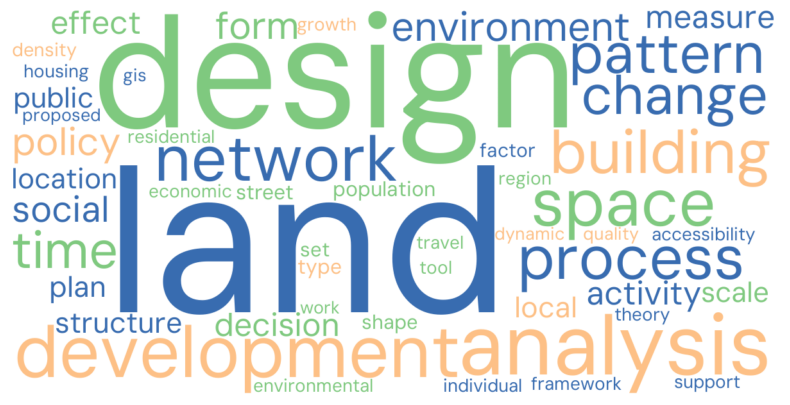

In [57]:
__gen_cloud_3_color__(full_freq[:50])

## 1 .4 Each decade 

In [58]:
df70_freq = __pre_process__(df70, epb_stop_words)
df70_freq

design            66
building          42
set               40
space             38
theory            34
                  ..
overconstraint     1
normally           1
list               1
bar                1
intersection       1
Name: count, Length: 1651, dtype: int64

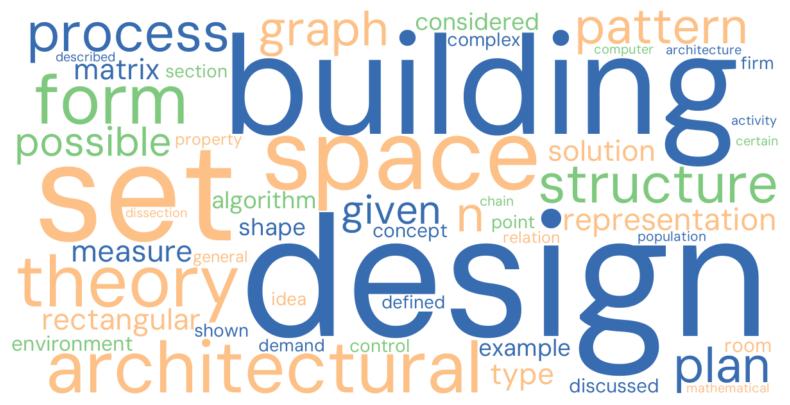

In [546]:
__gen_cloud_3_color__(df70_freq[:50])

In [498]:
df80_freq = __pre_process__(df80, epb_stop_words)
df80_freq

design           182
development      117
analysis         112
structure         96
theory            90
                ... 
net                1
saved              1
invoke             1
tier               1
voluntaristic      1
Name: count, Length: 3675, dtype: int64

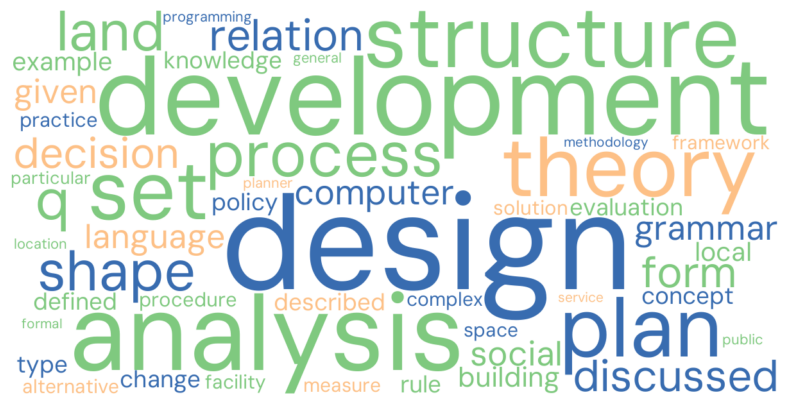

In [547]:
__gen_cloud_3_color__(df80_freq[:50])

In [360]:
df90_freq = __pre_process__(df90, epb_stop_words)
df90_freq

design          319
development     206
land            158
analysis        146
process         145
               ... 
interpretive      1
markov            1
chain             1
plagued           1
unclear           1
Name: count, Length: 5065, dtype: int64

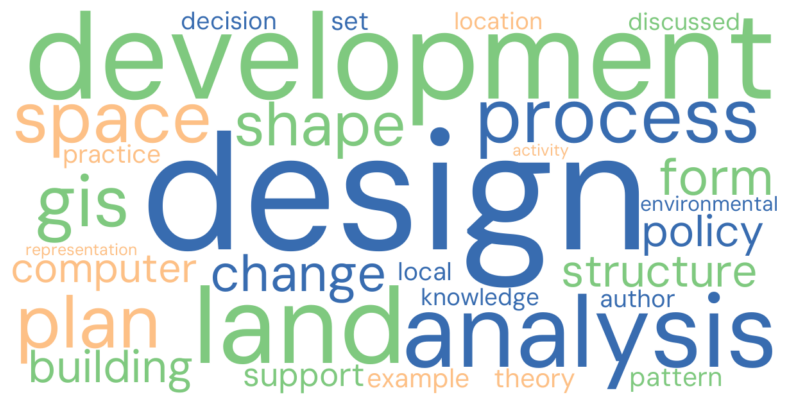

In [548]:
__gen_cloud_3_color__(df90_freq[:30])

In [361]:
df00_freq = __pre_process__(df00, epb_stop_words)
df00_freq

land            336
development     283
analysis        273
design          220
space           207
               ... 
manmade           1
chaotic           1
nonspatial        1
vital             1
occupational      1
Name: count, Length: 6052, dtype: int64

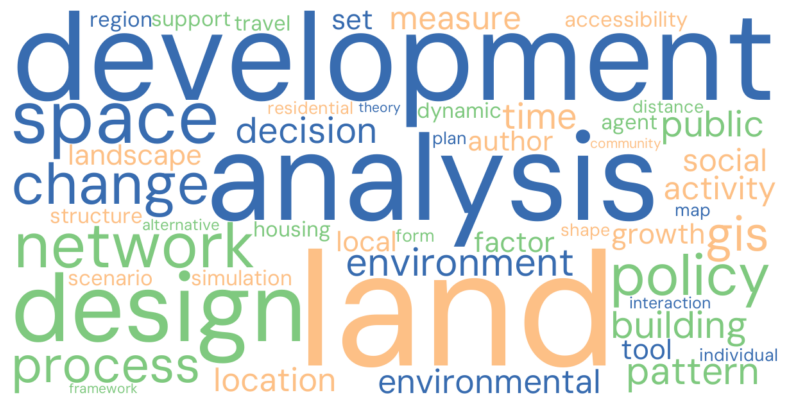

In [554]:
__gen_cloud_3_color__(df00_freq[:50])

In [363]:
df10_freq = __pre_process__(df10, epb_stop_words)
df10_freq

land           445
development    347
analysis       325
space          307
network        295
              ... 
ignorance        1
lawful           1
outer            1
attaining        1
gave             1
Name: count, Length: 6667, dtype: int64

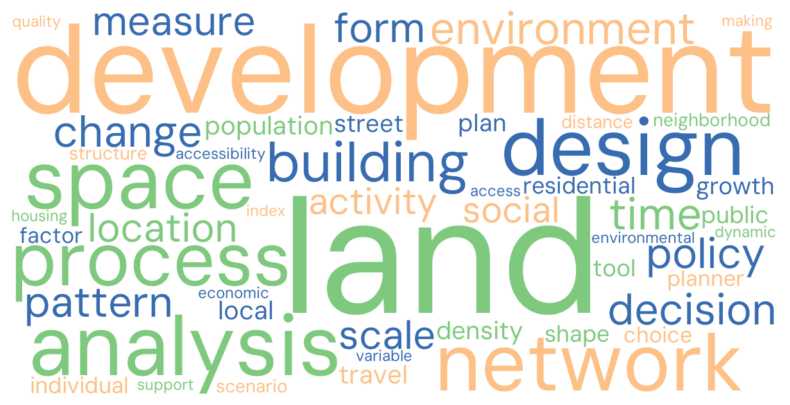

In [551]:
__gen_cloud_3_color__(df10_freq[:50])

In [365]:
df20_freq = __pre_process__(df20, epb_stop_words)
df20_freq

analysis        346
network         321
land            302
development     263
space           258
               ... 
affectively       1
judgement         1
motorisation      1
vicious           1
medoids           1
Name: count, Length: 6766, dtype: int64

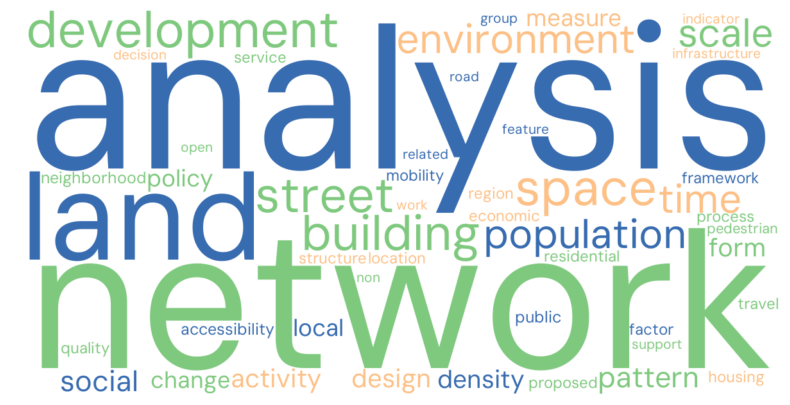

In [557]:
__gen_cloud_3_color__(df20_freq[:50])

## 2 Yearly Stat

### 2.1 paper published each year

In [59]:
#Pre-processing
#df['year'] = df['year'].fillna(0)
full_df['Publication Year'] = full_df['Publication Year'].astype(int)
full_df['amount'] = 1

In [60]:
df = full_df.loc[:, ["Publication Year", "amount"]]

In [61]:
df.head()

,Publication Year,amount
0,2020,1
1,2020,1
2,2020,1
3,2020,1
4,2020,1


In [62]:
#display histogram of yearly news amount
def DisplayNewsYearly(data):
    import matplotlib.pyplot as plt
    %matplotlib inline
    #fig = plt.figure()
    plt.figure(figsize=(25,10))
    #plt.style.use('ggplot')

    #x = list(data.year)
    x = list(data['Publication Year'])
    y = list(data.amount)
    x_pos = [i for i, _ in enumerate(x)]

    #'#469EB4', '#4E62AB'
    #plt.bar(x_pos, y, width=0.80, color='#43a2ca')
    plt.bar(x_pos, y, width=0.80, color='#469EB4')
    plt.xlabel("Year", fontsize = 24, fontname = "Arial")
    plt.ylabel("Paper Count", fontsize = 24, fontname = "Arial")

    plt.xticks(x_pos, x)

    plt.show()

In [63]:
yearcount = df.groupby(by=["Publication Year"]).sum().reset_index()
yearcount.loc[:, ['Publication Year', 'amount']].head()

,Publication Year,amount
0,1974,11
1,1975,10
2,1976,12
3,1977,14
4,1978,14


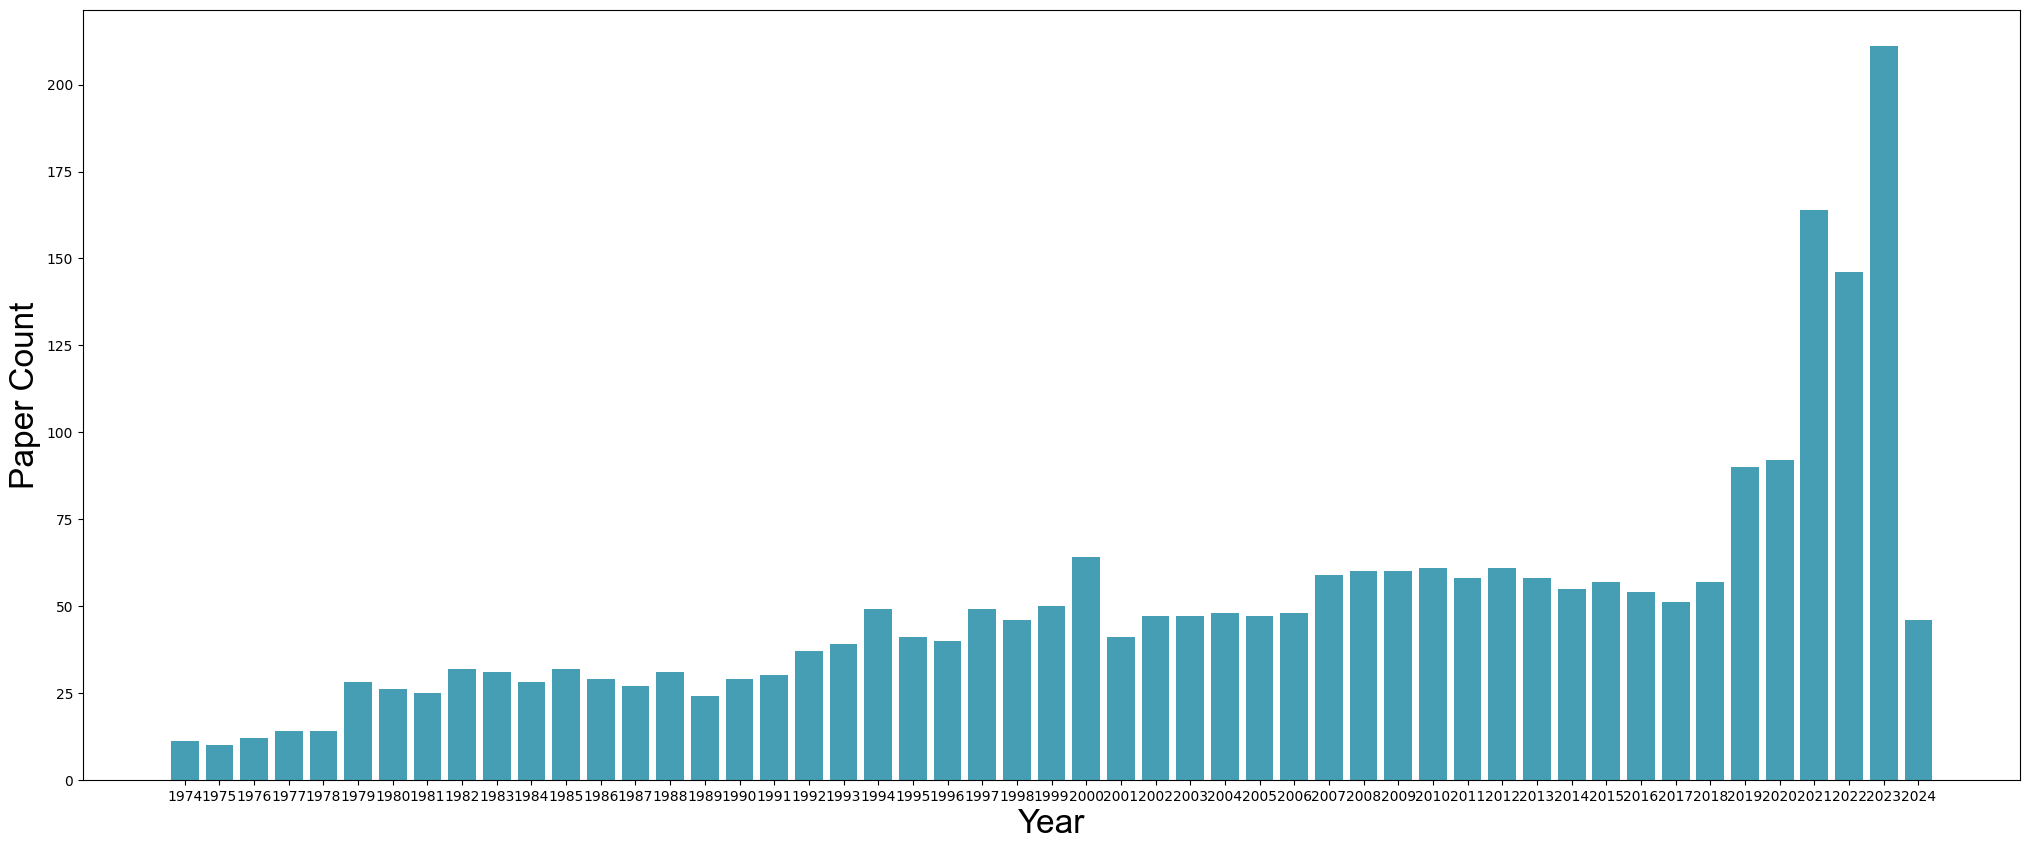

In [64]:
DisplayNewsYearly(yearcount.loc[:, ['Publication Year', 'amount']])

### 2.2 AVG Authorship by year

## 3 Topic Modeling 

In [0]:
#df['abstract'] = preprocess(df['Abstract Note'], )
#full_df['title_en'] = preprocess(full_df['Title'], epb_stop_words)

In [ ]:
#full_df['abstract'] = remove_stopwords(full_df['abstract'], epb_stop_words)

In [74]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired

In [75]:
#Documents for the inputs
#docs = list(full_df.loc[:,"abstract"].values)
docs = list(full_df.loc[:,"abstract"].values)
print("The length of the data is", len(docs))

The length of the data is 2566


In [106]:
#Sub-models
#1, Document Embedding
doc_embedding_model = SentenceTransformer("all-mpnet-base-v2") #high performance
#doc_embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


#2, Dimensionality Reduction
dimensionality_reduction = UMAP(n_neighbors = 15, n_components = 5,
                  min_dist=0.0, metric='cosine', random_state = 42)#generate consistent results

#3, Document Clustering
doc_clustering_model = HDBSCAN(min_cluster_size = 10, metric= 'euclidean', cluster_selection_method='eom', prediction_data=True)
#doc_clustering_model = HDBSCAN(min_cluster_size=10, metric= 'euclidean', cluster_selection_method='eom', prediction_data=True)

#4, Topic representation: fine-tuning the topic representation
#4.1 CountVectorizer
#vectorizer_model_tuning = CountVectorizer(stop_words="english", min_df = 5)
vectorizer_model_tuning = CountVectorizer(ngram_range = (1,2), stop_words="english", min_df = 5)

#4.2 TF-IDF
#ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)
#ctfidf_model = ClassTfidfTransformer(bm25_weighting=True)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
#ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
#representation_model = KeyBERTInspired()

### 2.1.2 Results Tuning
#### 2.1.2.1 No Tuning

In [107]:
#Application topic model
topic_model_nt = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [108]:
topics, probs= topic_model_nt.fit_transform(docs)

2024-03-01 13:00:49,849 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

2024-03-01 13:01:00,225 - BERTopic - Embedding - Completed ✓
2024-03-01 13:01:00,225 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-03-01 13:01:07,177 - BERTopic - Dimensionality - Completed ✓
2024-03-01 13:01:07,178 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-03-01 13:01:07,223 - BERTopic - Cluster - Completed ✓
2024-03-01 13:01:07,223 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-03-01 13:01:07,411 - BERTopic - Representation - Completed ✓
2024-03-01 13:01:07,411 - BERTopic - Topic reduction - Reducing number of topics
2024-03-01 13:01:07,600 - BERTopic - Topic reduction - Reduced number of topics from 48 to 41


In [109]:
freq1 = topic_model_nt.get_topic_info()#good
freq1

,Topic,Count,Name,Representation,Representative_Docs
0,-1,852,-1_development_land_space_analysis,"[development, land, space, analysis, building,...",[people enjoy benefit car brings quality life ...
1,0,289,0_network_travel_transport_transportation,"[network, travel, transport, transportation, t...",[environment shown influence active transporta...
2,1,120,1_shape_grammar_design_language,"[shape, grammar, design, language, rule, style...",[concept emergence root th century philosophy ...
3,2,81,2_theory_practice_plan_strategic,"[theory, practice, plan, strategic, education,...",[implicit paradigm theory call design discipli...
4,3,75,3_design_designer_style_knowledge,"[design, designer, style, knowledge, architect...",[attempt track path architectural design desig...
5,4,70,4_visibility_space_virtual_isovist,"[visibility, space, virtual, isovist, visual, ...",[article explored feasibility dimensional visi...
6,5,67,5_land_ca_automaton_cellular,"[land, ca, automaton, cellular, change, simula...",[published explored heterogeneity land change ...
7,6,66,6_gis_geographic_technology_mapping,"[gis, geographic, technology, mapping, analysi...",[popularity internet technology brought fundam...
8,7,58,7_rectangular_room_architectural_adjacency,"[rectangular, room, architectural, adjacency, ...",[describes computer aided design package layou...
9,8,54,8_park_covid_pandemic_vibrancy,"[park, covid, pandemic, vibrancy, neighborhood...",[crucial understand current pattern park visit...


#### 2.1.2.2 Only CV
Apply CV after Get Results

In [80]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model_tuning_after = CountVectorizer(ngram_range = (1,2), stop_words="english", min_df = 5)

topic_model_nt.update_topics(docs, vectorizer_model = vectorizer_model_tuning_after)

In [81]:
#No tuning
freq2 = topic_model_nt.get_topic_info()#good
freq2

,Topic,Count,Name,Representation,Representative_Docs
0,-1,911,-1_development_land_space_analysis,"[development, land, space, analysis, process, ...",[economic downturn social change migration sha...
1,0,1314,0_design_network_land_analysis,"[design, network, land, analysis, development,...",[dispersed development often associated negati...
2,1,119,1_shape_design_rule_plan,"[shape, design, rule, plan, language, generati...",[shape grammar structured generating design su...
3,2,40,2_facility_solution_location_heuristic,"[facility, solution, location, heuristic, medi...",[decided bent toward optimal solution given fa...
4,3,35,3_hazard_risk_mitigation_response,"[hazard, risk, mitigation, response, service, ...",[physical infrastructure network diverse settl...
5,4,31,4_covid_pandemic_covid pandemic_health,"[covid, pandemic, covid pandemic, health, neig...",[past year china wrested domestic control covi...
6,5,24,5_dimension_form_curve_scale,"[dimension, form, curve, scale, architecture, ...",[analysis development tel aviv metropolis conc...
7,6,19,6_environment_measurement_street_propagation,"[environment, measurement, street, propagation...",[role sound environment recently received incr...
8,7,19,7_effect_occurrence_prediction_bus,"[effect, occurrence, prediction, bus, agent, t...",[established criminological scholarship crime ...
9,8,16,8_pollution_quality_traffic_concentration,"[pollution, quality, traffic, concentration, e...",[particulate matter pm generates variety negat...


#### 2.1.2.2Apply CV When Get Results

In [110]:
#Application topic model
topic_model_cv = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       vectorizer_model = vectorizer_model_tuning,#4.1
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [111]:
topics_2, probs= topic_model_cv.fit_transform(docs)

2024-03-01 13:01:22,192 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

2024-03-01 13:01:32,872 - BERTopic - Embedding - Completed ✓
2024-03-01 13:01:32,873 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-03-01 13:01:39,859 - BERTopic - Dimensionality - Completed ✓
2024-03-01 13:01:39,860 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-03-01 13:01:39,905 - BERTopic - Cluster - Completed ✓
2024-03-01 13:01:39,905 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-03-01 13:01:40,326 - BERTopic - Representation - Completed ✓
2024-03-01 13:01:40,326 - BERTopic - Topic reduction - Reducing number of topics
2024-03-01 13:01:40,779 - BERTopic - Topic reduction - Reduced number of topics from 48 to 41


In [112]:
freq3 = topic_model_cv.get_topic_info()#good
freq3

,Topic,Count,Name,Representation,Representative_Docs
0,-1,852,-1_development_land_space_analysis,"[development, land, space, analysis, building,...",[published consecutively taken together accoun...
1,0,289,0_network_travel_transport_transportation,"[network, travel, transport, transportation, t...",[provides unique long investigation regional t...
2,1,120,1_shape_grammar_shape grammar_design,"[shape, grammar, shape grammar, design, langua...",[decidability relation shape grammar considere...
3,2,81,2_theory_practice_plan_strategic,"[theory, practice, plan, strategic, education,...",[implicit paradigm theory call design discipli...
4,3,75,3_design_designer_style_architectural,"[design, designer, style, architectural, knowl...",[capture design knowledge transfer development...
5,4,70,4_visibility_space_virtual_visual,"[visibility, space, virtual, visual, environme...",[measure visibility space presented concept is...
6,5,67,5_land_ca_automaton_cellular,"[land, ca, automaton, cellular, cellular autom...",[cellular automaton ca individual state time s...
7,6,66,6_gis_geographic_technology_mapping,"[gis, geographic, technology, mapping, geograp...",[popularity internet technology brought fundam...
8,7,58,7_rectangular_room_architectural_adjacency,"[rectangular, room, architectural, adjacency, ...",[rectangular floorplan always satisfy requirem...
9,8,54,8_park_covid_pandemic_neighborhood,"[park, covid, pandemic, neighborhood, health, ...",[globally dramatic change park visitation acco...


#### 2.1.2.3 Only TF-IDF

In [113]:
#Application topic model
topic_model_tfidf = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       ctfidf_model = ctfidf_model,#4.2
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [114]:
topics_3, probs= topic_model_tfidf.fit_transform(docs)

2024-03-01 13:02:05,394 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

2024-03-01 13:02:15,695 - BERTopic - Embedding - Completed ✓
2024-03-01 13:02:15,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-03-01 13:02:22,680 - BERTopic - Dimensionality - Completed ✓
2024-03-01 13:02:22,681 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-03-01 13:02:22,726 - BERTopic - Cluster - Completed ✓
2024-03-01 13:02:22,726 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-03-01 13:02:22,920 - BERTopic - Representation - Completed ✓
2024-03-01 13:02:22,920 - BERTopic - Topic reduction - Reducing number of topics
2024-03-01 13:02:23,107 - BERTopic - Topic reduction - Reduced number of topics from 48 to 41


In [118]:
freq4 = topic_model_tfidf.get_topic_info()#good
freq4

,Topic,Count,Name,Representation,Representative_Docs
0,-1,852,-1_development_land_space_analysis,"[development, land, space, analysis, building,...",[published consecutively taken together accoun...
1,0,289,0_network_travel_transport_transportation,"[network, travel, transport, transportation, t...",[transportation u traditionally focused automo...
2,1,120,1_shape_grammar_shape grammar_design,"[shape, grammar, shape grammar, design, langua...",[following parametric shape grammar generates ...
3,2,81,2_theory_practice_plan_strategic,"[theory, practice, plan, strategic, education,...",[emergence development profession closely tied...
4,3,75,3_design_designer_style_architectural,"[design, designer, style, architectural, knowl...",[literature suggests design plan inadequate de...
5,4,70,4_visibility_space_virtual_visual,"[visibility, space, virtual, visual, environme...",[question whether multilevel building memorize...
6,5,67,5_land_ca_automaton_cellular,"[land, ca, automaton, cellular, cellular autom...",[generalization cellular automaton allows flex...
7,6,66,6_gis_geographic_technology_mapping,"[gis, geographic, technology, mapping, geograp...",[pressing rapid urbanisation kuala lumpur incl...
8,7,58,7_rectangular_room_architectural_adjacency,"[rectangular, room, architectural, adjacency, ...",[procedure described generates dissection rect...
9,8,54,8_park_covid_pandemic_neighborhood,"[park, covid, pandemic, neighborhood, health, ...",[york nyc epicenter covid pandemic long time g...


#### 2.1.2.3 TF-IDF + CV (** we used this in the paper **)
Apply CV after

In [122]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model_tuning_after = CountVectorizer(ngram_range = (1,2), stop_words="english", min_df = 5)
#topic_model_nt.update_topics(docs, vectorizer_model = vectorizer_model_tuning_after)
topic_model_tfidf.update_topics(docs, vectorizer_model = vectorizer_model_tuning_after )

In [123]:
freq5 = topic_model_tfidf.get_topic_info()#good
freq5

,Topic,Count,Name,Representation,Representative_Docs
0,-1,852,-1_development_land_space_analysis,"[development, land, space, analysis, building,...",[published consecutively taken together accoun...
1,0,289,0_network_travel_transport_transportation,"[network, travel, transport, transportation, t...",[transportation u traditionally focused automo...
2,1,120,1_shape_grammar_shape grammar_design,"[shape, grammar, shape grammar, design, langua...",[following parametric shape grammar generates ...
3,2,81,2_theory_practice_plan_strategic,"[theory, practice, plan, strategic, education,...",[emergence development profession closely tied...
4,3,75,3_design_designer_style_architectural,"[design, designer, style, architectural, knowl...",[literature suggests design plan inadequate de...
5,4,70,4_visibility_space_virtual_visual,"[visibility, space, virtual, visual, environme...",[question whether multilevel building memorize...
6,5,67,5_land_ca_automaton_cellular,"[land, ca, automaton, cellular, cellular autom...",[generalization cellular automaton allows flex...
7,6,66,6_gis_geographic_technology_mapping,"[gis, geographic, technology, mapping, geograp...",[pressing rapid urbanisation kuala lumpur incl...
8,7,58,7_rectangular_room_architectural_adjacency,"[rectangular, room, architectural, adjacency, ...",[procedure described generates dissection rect...
9,8,54,8_park_covid_pandemic_neighborhood,"[park, covid, pandemic, neighborhood, health, ...",[york nyc epicenter covid pandemic long time g...


#### 2.1.2.4 Apply CV and TF-IDF at the same time

In [124]:
#Application topic model
topic_model_cv_tfidf = BERTopic(embedding_model = doc_embedding_model, #1
                       umap_model = dimensionality_reduction,#2
                       hdbscan_model = doc_clustering_model,#3
                       vectorizer_model = vectorizer_model_tuning,#4.1
                       ctfidf_model = ctfidf_model,#4.2
                       top_n_words = 15, min_topic_size=15, nr_topics='auto',
                       language = "english", calculate_probabilities = False, verbose = True)

In [125]:
topics_4, probs= topic_model_cv_tfidf.fit_transform(docs)

2024-03-01 13:04:21,109 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

2024-03-01 13:04:31,588 - BERTopic - Embedding - Completed ✓
2024-03-01 13:04:31,588 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-03-01 13:04:38,551 - BERTopic - Dimensionality - Completed ✓
2024-03-01 13:04:38,551 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-03-01 13:04:38,597 - BERTopic - Cluster - Completed ✓
2024-03-01 13:04:38,597 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-03-01 13:04:39,019 - BERTopic - Representation - Completed ✓
2024-03-01 13:04:39,019 - BERTopic - Topic reduction - Reducing number of topics
2024-03-01 13:04:39,433 - BERTopic - Topic reduction - Reduced number of topics from 48 to 41


In [126]:
freq6 = topic_model_cv_tfidf.get_topic_info()
freq6

,Topic,Count,Name,Representation,Representative_Docs
0,-1,852,-1_development_sustainability_environmental_ho...,"[development, sustainability, environmental, h...",[post early historical attempted reverse dilem...
1,0,289,0_network_transport_travel_traffic,"[network, transport, travel, traffic, transpor...",[street network aspect contains crucial organi...
2,1,120,1_grammar_shape_shape grammar_language,"[grammar, shape, shape grammar, language, rule...",[shape grammar implementation largely concerne...
3,2,81,2_strategic_education_theory_discourse,"[strategic, education, theory, discourse, prac...",[emergence development profession closely tied...
4,3,75,3_design_designer_style_design process,"[design, designer, style, design process, sket...",[expert suggest design plan u lack adequate co...
5,4,70,4_visibility_virtual_visible_virtual environment,"[visibility, virtual, visible, virtual environ...",[researcher studying environmental perception ...
6,5,67,5_ca_automaton_cellular automaton_cellular,"[ca, automaton, cellular automaton, cellular, ...",[cellular automaton traditionally employed reg...
7,6,66,6_gis_geographic gis_geographic_mapping,"[gis, geographic gis, geographic, mapping, tec...",[comprehensive definition building database sd...
8,7,58,7_rectangular_adjacency_room_floor plan,"[rectangular, adjacency, room, floor plan, arc...",[theoretical experimental implementation compu...
9,8,54,8_covid_park_pandemic_covid pandemic,"[covid, park, pandemic, covid pandemic, vitali...",[spread covid pandemic provoked policy restric...


## 3.2 Topic Overtime

In [601]:
#Create list contains all year
full_df['year'] = full_df['Publication Year'].astype(int)
timestamps = full_df['Publication Year'].to_list()
len(timestamps)

2566

In [602]:
topics_over_time = topic_model_cv_tfidf.topics_over_time(docs, timestamps, nr_bins=None,
                                                datetime_format=None,
                                                evolution_tuning=True,
                                                global_tuning=True)

51it [00:00, 65.22it/s] 


In [603]:
topic_model_tfidf.visualize_topics_over_time(topics_over_time)

In [604]:
t_list = []
for i in range(10, 24):
    #print(i)
    t_list.append(i)
topic_model_tfidf.visualize_topics_over_time(topics_over_time, topics = [5, 17])

In [585]:
similar_topics, similarity = topic_model_tfidf.find_topics("computer", top_n=5)
#topic_model_tfidf.get_topic(similar_topics[0])
similar_topics

[17, 10, 5, 8, -1]

In [425]:
from src.topicvisual import GetTopicEvo
from src.topicvisual import GetTopicCountByYear
from src.topicvisual import VisualizeStackByYearColor
from src.topicvisual import _visualsmall_

In [442]:
###################
# Part 2 Stack Bars
###################
# * Step1: Get the dataframe for the visualization
def GetTopicCountByYear(topiclist, evo_table, yearlycount):
    # extract the key info from eveolution table
    temp_df = evo_table.loc[:, ['Topic', 'Frequency', 'Timestamp']]
    # print(temp_df)

    # Loop through the keywords list to draw lins on Cavas
    topiclist.sort()
    # print("TopicList", topiclist)
    legend_list = []

    # Create a dataframe to hold the all topics, freq, year amount
    stack_df = pd.DataFrame()

    for item in range(0, len(topiclist)):
        topic = topiclist[item]
        topic_label = "Topic " + str(topic)
        # print("Topic", topic)
        legend_list.append("Topic" + str(topic))

        # Extract visulize dataframe
        visual_df = temp_df[temp_df.Topic == topic].reset_index(drop=True)
        visual_df = visual_df.rename(columns={'Timestamp': 'Publication Year'})  # rename timstamp to year fro merge
        #print(visual_df.head())
        #print(yearcount.head())
        # Merge on year
        final_visual_df = pd.merge(visual_df, yearlycount, on="Publication Year")
        # print(final_visual_df.head())
        #stack_df = stack_df.append(final_visual_df)
        stack_df = pd.concat([stack_df, final_visual_df])

    # group the df based on year and topics
    #grouped_stack = stack_df.groupby(["year", "Topic"])["Frequency"].sum().reset_index()
    grouped_stack = stack_df.groupby(["Publication Year", "Topic"])["Frequency"].sum().reset_index()
    # pivot the dataframe into the correct format
    grouped_stack_df = grouped_stack.pivot(index='Publication Year', columns='Topic', values='Frequency').fillna(0).reset_index()
    # print(grouped_stack_df.head())

    return grouped_stack_df


# * Step2: Satcked bar visualization
# Get the topic evo for each topic
def GetTopicEvo(topiclist, overtime):  # topics list, topic_model, topic over time dataframe
    finaldataframe = pd.DataFrame()
    for topic in topiclist:
        # print(topic)
        tempdf = overtime[overtime.Topic == topic].reset_index(drop=True)
        # print(tempdf.head())
        # finaldataframe = finaldataframe.append(tempdf)
        finaldataframe = pd.concat([finaldataframe, tempdf])
    return finaldataframe


def VisualizeStackByYearColor(data, year_range, PlotTitle):  # 3String
    plt.style.use('default')

    # create the figure
    fig, ax = plt.subplots(figsize=(25, 10))
    # plt.figure(figsize=(25,10))
    plt.xlabel('Year', fontsize=30, fontname="Arial")
    plt.ylabel('Frequency', fontsize=30, fontname="Arial")

    print(len(data.columns[1:]))
    if len(data.columns[1:]) == 2:
        color_list = ['#4E62AB', '#FDB96A']

    if len(data.columns[1:]) == 3:
        color_list = ['#4E62AB', '#FDB96A', '#D6404E']

    if len(data.columns[1:]) == 4:
        color_list = ['#4E62AB', '#87CFA4', '#FDB96A', '#D6404E']

    if len(data.columns[1:]) == 5:
        color_list = ['#4E62AB', '#87CFA4', '#F5FBB1', '#FDB96A', '#D6404E']

    if len(data.columns[1:]) == 6:
        color_list = ['#4E62AB', '#87CFA4', '#CBE99D', '#FEE89A', '#F57547', '#9E0142']

    if len(data.columns[1:]) == 7:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#FEE89A', '#FDB96A', '#F57547', '#9E0142']

    if len(data.columns[1:]) == 8:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#F5FBB1', '#FEE89A', '#FDB96A', '#F57547', '#9E0142']

    if len(data.columns[1:]) == 9:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#F5FBB1', '#FEE89A', '#FDB96A', '#F57547', '#D6404E', '#9E0142']

    # Legend of the stacked bars
    bottom = 0
    colorid = 0
    legend_list = []
    for topic in data.columns[1:]:
        # legend
        topic_label = "Topic " + str(topic)
        # print("Topic", topic)
        legend_list.append("Topic" + str(topic))
        # bar plot
        # plt.bar(data.loc[:, 'year'], data[topic], bottom = bottom, width=0.95)
        plt.bar(data.index, data[topic], bottom=bottom, width=0.95, color=color_list[colorid])
        bottom = bottom + data[topic]
        colorid = colorid + 1

    # ax.set_title(PlotTitlem)
    plt.legend((legend_list), prop={'family': 'Arial', "size": 20}, loc='upper left', ncol=1)

    # set x ticks: dont' show the year without any topics
    #x_label = list(np.arange(data.year.min(), 2021, 5))
    #x_label.append(2021)
    #x_label = list(data.year)
    x_label = list(data["Publication Year"])
    print(x_label)

    x_ticks = []
    for year_index in range(0, len(x_label)):
        #print(year)
        year = x_label[year_index]
        try:
            temp = data[data['Publication Year'] == year].index[0]
            #print(temp)
        except:
            temp = data[data['Publication Year'] == year + 1].index[0]
        #if temp%5 == 0:
        x_ticks.append(temp)
    print(x_ticks)

    # x_ticks = data.index.to_list()
    # x_label = data.loc[:, 'year'].to_list()
    # x_label = np.arange(1975, 2021, 5)
    # Plot x and y axticks
    plt.gcf().autofmt_xdate()  # italics of x label
    plt.xticks(ticks=x_ticks, labels=x_label, fontsize=15)
    # plt.xticks(np.arange(1975, 2021, 5))
    plt.yticks(fontsize=25)
    plt.margins(x=0.01)
    plt.show()

def _visualsmall_(data, year_range):
    plt.style.use('default')

    print(len(data.columns[1:]))
    if len(data.columns[1:]) == 2:
        color_list = ['#4E62AB', '#FDB96A']

    if len(data.columns[1:]) == 3:
        color_list = ['#4E62AB', '#FDB96A', '#D6404E']

    if len(data.columns[1:]) == 4:
        color_list = ['#4E62AB', '#87CFA4', '#FDB96A', '#D6404E']

    if len(data.columns[1:]) == 5:
        color_list = ['#4E62AB', '#87CFA4', '#F5FBB1', '#FDB96A', '#D6404E']

    if len(data.columns[1:]) == 6:
        color_list = ['#4E62AB', '#87CFA4', '#CBE99D', '#FEE89A', '#F57547', '#9E0142']

    if len(data.columns[1:]) == 7:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#FEE89A', '#FDB96A', '#F57547', '#9E0142']

    if len(data.columns[1:]) == 8:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#F5FBB1', '#FEE89A', '#FDB96A', '#F57547', '#9E0142']

    if len(data.columns[1:]) == 9:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#F5FBB1', '#FEE89A', '#FDB96A', '#F57547', '#D6404E', '#9E0142']
    # ax = plt.axes()
    if year_range > 0:
        # figure and axis
        fig, ax = plt.subplots(1, figsize=(16, 9))
        plt.xlabel('Year', fontsize=20, fontname="Arial")

        print("Small plot is the topic before the year of ", year_range)
        #year_index = data[data['year'] == year_range].index[0]
        year_index = data[data['Publication Year'] == year_range].index[0]
        # print(year_index.tolist())
        small_df = data.iloc[:year_index, :]  # .set_index('year')
        # print(small_df.tail())

        bottom = 0
        colorid = 0
        for topic in data.columns[1:]:
            # bar plot
            # plt.bar(small_df.loc[:, 'year'], small_df[topic], bottom = bottom, width=0.95)
            plt.bar(small_df.index, small_df[topic], bottom=bottom, width=0.95, color=color_list[colorid])
            bottom = bottom + small_df[topic]
            colorid = colorid + 1

        # remove spines
        # ax.spines['right'].set_visible(False)
        # ax.spines['left'].set_visible(False)
        # ax.spines['top'].set_visible(False)
        # ax.spines['bottom'].set_visible(False)
        x_ticks = small_df.index
        #x_label = small_df.loc[:, 'year'].to_list()
        x_label = small_df.loc[:, 'Publication Year'].to_list()

        plt.gcf().autofmt_xdate()  # italics of x label
        plt.xticks(ticks=x_ticks, labels=x_label, fontsize=15)
        plt.yticks(fontsize=25)
        plt.margins(x=0.01)
        plt.show()


###############################END OF PART TWO#############################################


3
[1976, 1977, 1978, 1979, 1982, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2017, 2019, 2020, 2021, 2022, 2023, 2024]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


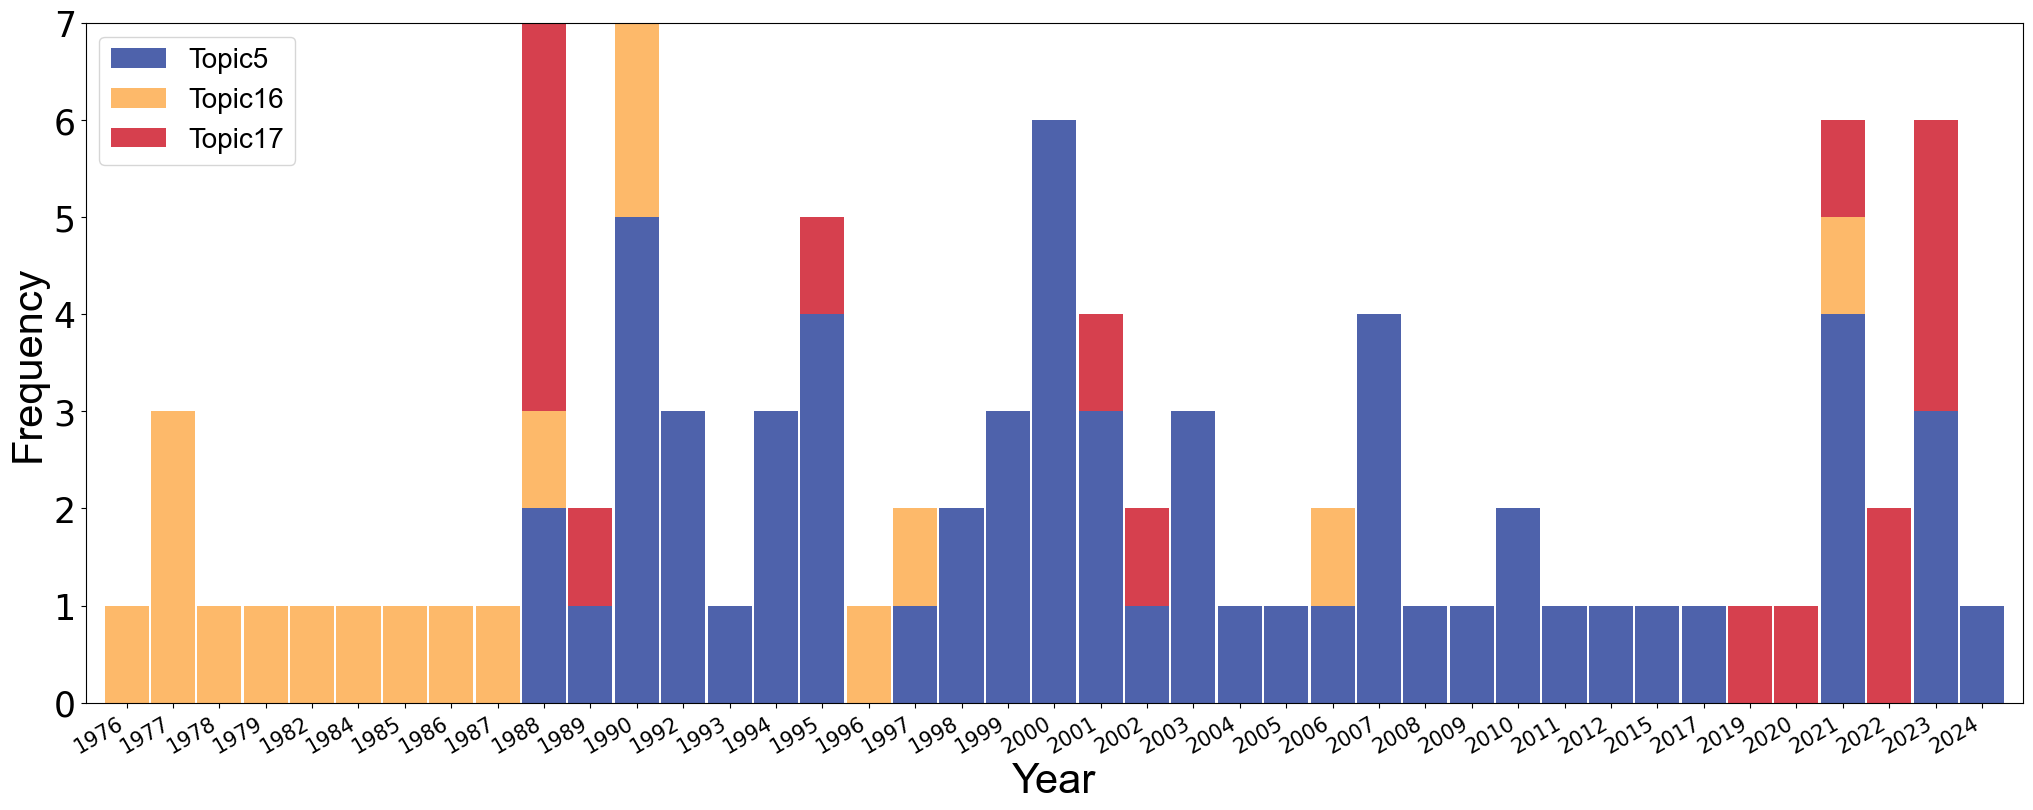

In [587]:
select_topic = [5, 16,17]
evo3_10 = GetTopicEvo(select_topic, topics_over_time)

evo3_10_count_yearly = GetTopicCountByYear(select_topic, topics_over_time , yearcount.set_index('Publication Year'))
VisualizeStackByYearColor(evo3_10_count_yearly, 2023, "Test")

In [566]:
#natural break 
import jenkspy

In [575]:
# Extract the column you want to perform natural breaks on
col_to_break = freq5['Count'][1:]
col_to_break

1     562
2     331
3     115
4      71
5      63
6      61
7      44
8      41
9      40
10     30
11     28
12     28
13     25
14     22
15     19
16     18
17     18
18     16
19     15
20     14
21     14
22     12
23     11
24     10
Name: Count, dtype: int64

In [574]:
# Define the number of breaks you want to find
num_breaks = 5

# Find the natural breaks
breaks = jenkspy.jenks_breaks(col_to_break, num_breaks)
print("Natural breaks:", breaks)

Natural breaks: [10, 30, 71, 115, 331, 562]


In [605]:

# create a data frame with topic number along with its freq and all words
def _get_topic_allwords_(all_topics, t_model):
    topic_list = []
    freq_list = []
    words_list = []

    for topic in all_topics:
        topic_name = "Topic" + str(topic)
        topic_list.append(topic_name)
        # print(topic_name)
        frq = t_model.get_topic_freq(topic)
        freq_list.append(frq)
        wordset = t_model.get_topic(topic)[:15]
        # print("====Get item from get_topic Results====")
        topic_word = []
        for item in wordset:
            # print()
            # topic_word += '' + str(item[0])
            topic_word.append(item[0])

        words_list.append(topic_word)
    # words_list.append(join(topic_word))
    topics_df = pd.DataFrame(list(zip(topic_list, freq_list, words_list)), columns=['Topic', 'Freq', 'Words'])
    return topics_df

In [606]:
cv_tf_ft_topic = _get_topic_allwords_(freq6.Topic, topic_model_cv_tfidf)
#freq1.Topic, topic_model_nt
cv_tf_ft_topic

,Topic,Freq,Words
0,Topic-1,958,"[land, space, development, housing, analysis, ..."
1,Topic0,562,"[segregation, design, theory, energy, house, p..."
2,Topic1,331,"[network, travel, pedestrian, transport, route..."
3,Topic2,115,"[shape, language, rule, parametric, style, sch..."
4,Topic3,71,"[water, hazard, resilience, recovery, mitigati..."
5,Topic4,63,"[visibility, isovist, visible, visual, visuali..."
6,Topic5,61,"[gis, geographic, internet, mapping, user, tec..."
7,Topic6,44,"[ca, automaton, cellular automaton, cellular, ..."
8,Topic7,41,"[facility, median, heuristic, solution, coveri..."
9,Topic8,40,"[shopping, retail, store, internet, centre, co..."


In [594]:
cv_tf_ft_topic.to_csv('results/topics_cv_tf_ft_topic.csv')

In [596]:
#save model
#1,nonfliter; 2,withseed; 3,hperform; 4,remove stop word; 5, auto_drop
topic_model_cv_tfidf.save("results/model_cv_tfidf")
#save topics to list
df = pd.DataFrame(data={"col1": topics_3})
df.to_csv("results/topics_from_model_cv_tfidf.csv", sep=',',index=False)

2024-03-01 11:48:34,966 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
